In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

In [39]:
N = 6
wd = 0.6365091993031289
wm = 1.0
tlist = np.linspace(0, 200, 600)
args = {"A": 0.1, "omega": wd}

dx = 0.0
dy = 0.0
dz = 0.6

H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, ham_disorder=[dz, dy, dx], random_seed=False)
H = qt.QobjEvo([H0, [H1, coeff]], args=args)
psi_t = qt.sesolve(H, eigenstates[0], tlist)


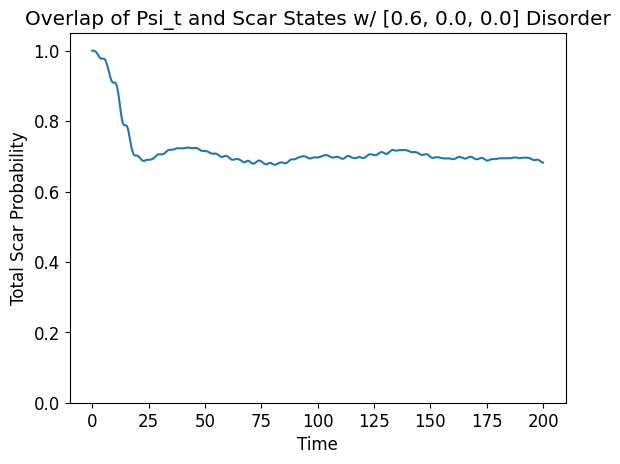

[0, 1, 4, 7, 13, 16, 17]


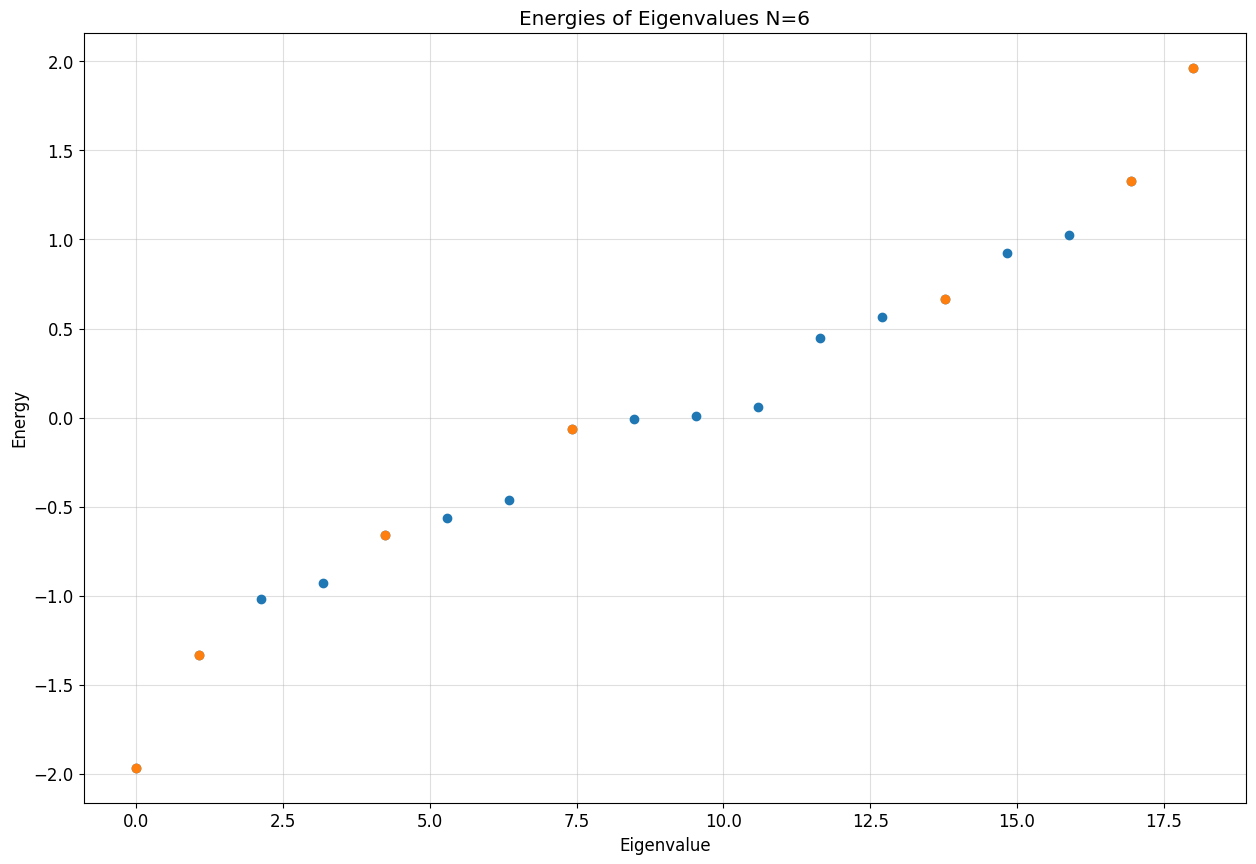

In [40]:
scarIndices = giveMeScarOverlap(N, psi0, tlist, plot_scars=False, disorder=[dz, dy, dx], reals=200, args=args)
print(scarIndices)

plt.figure(figsize=(15, 10))

eigenvalues = H0.eigenenergies()
xlist = np.linspace(0, len(eigenvalues), len(eigenvalues))
plt.plot(xlist, eigenvalues, ".", ms=12)

slist = []
scarVals = []
for i in scarIndices:
    slist.append(xlist[i])
    scarVals.append(eigenvalues[i])

plt.plot(slist, scarVals, ".", ms=12)
plt.grid(True)
plt.xlabel("Eigenvalue")
plt.ylabel("Energy")
plt.grid(True, alpha=0.4)
plt.title(f"Energies of Eigenvalues N={N}")
plt.show()

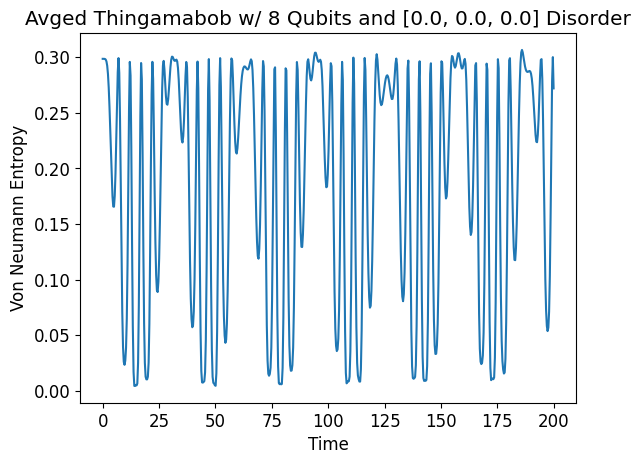

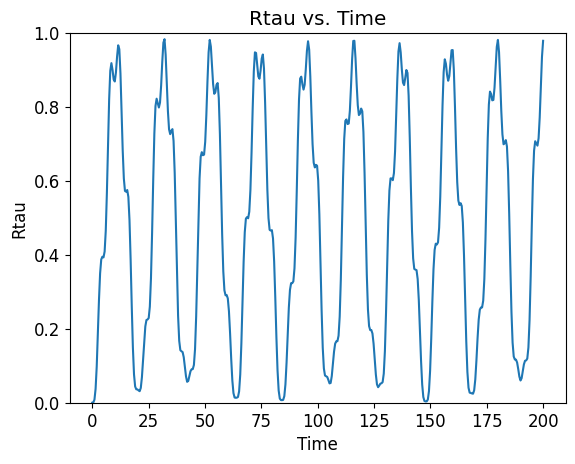

In [4]:

giveMeVonNeumannEntrop(N, wd, tlist, disorder=[dz, dy, dx], reals=50)
Rtau_plot(H0, H1, N, w=wd, indv_qubit=False, freq_dis=0.0, args=args, t=200)